# 🎬 Workshop NLP Sesi 1: Traditional ML & AutoML — IMDB Sentiment

**Mata Kuliah:** Pemrosesan Bahasa Alami (SD25-32202)  
**Topik:** Klasifikasi Sentimen Review Film dengan *Traditional Machine Learning* menggunakan AutoML (PyCaret)

---

## 🎯 Apa yang Akan Kita Pelajari?

Dalam workshop ini, kita akan membangun sebuah **model klasifikasi sentimen** yang bisa mendeteksi apakah sebuah review film bersifat **positif** atau **negatif**. Kita akan belajar:

1. **Text Preprocessing** — Bagaimana membersihkan teks review yang mengandung HTML, kontraksi, dan noise lainnya
2. **Feature Extraction (TF-IDF)** — Bagaimana komputer "memahami" teks dengan mengubahnya jadi angka
3. **AutoML** — Membandingkan banyak algoritma ML sekaligus tanpa coding manual
4. **Evaluasi Model** — Mengukur seberapa bagus model kita

---

## 📊 Tentang Dataset

Kita menggunakan **IMDB Dataset of 50K Movie Reviews** dari Kaggle — salah satu *benchmark* paling populer untuk *sentiment analysis*.

| Info | Detail |
|------|--------|
| Sumber | Kaggle (lakshmi25npathi) |
| Jumlah Data | 50.000 review film |
| Bahasa | Inggris |
| Tugas | Binary Sentiment Classification |

**2 Label Klasifikasi:**
- 🟢 **Positive** — Review positif (menyukai film)
- 🔴 **Negative** — Review negatif (tidak suka film)

> **Kenapa dataset ini menarik?** Review film IMDB memiliki teks yang panjang, ekspresif, dan mengandung tag HTML dari web scraping. Ini adalah tantangan nyata dalam NLP — model harus memahami konteks kalimat yang kompleks, bukan sekadar kata kunci!

---
## 📦 Langkah 1: Instalasi & Import

Pertama, kita install semua library yang dibutuhkan. Library utama:
- **`pycaret`** — Framework AutoML yang memudahkan kita membandingkan banyak model sekaligus
- **`kagglehub`** — Untuk mendownload dataset dari Kaggle secara otomatis
- **`pandas`** — Untuk manipulasi data tabel

In [ ]:
# Install dependencies (jalankan sekali saja)
!pip install -q pycaret pandas kagglehub opendatasets matplotlib seaborn

In [1]:
# Import modul-modul yang sudah kita buat
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from config import RAW_CSV, TEXT_COL, LABEL_COL
from download_data import download_dataset
from preprocess import load_and_clean, show_cleaning_examples, clean_text
from train import (
    setup_pycaret,
    compare_all_models,
    tune_best,
    evaluate,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_class_report,
    finalize_and_save,
)

import pandas as pd
pd.set_option('display.max_colwidth', 80)

print("✅ Semua modul berhasil diimport!")

✅ Semua modul berhasil diimport!


---
## 📥 Langkah 2: Download Dataset

Kita akan mendownload dataset secara **otomatis** dari Kaggle. Fungsi ini "pintar" — kalau dataset sudah pernah didownload, dia akan langsung *skip* (tidak download ulang).

> **Bagaimana cara kerjanya?**  
> Kita menggunakan library `kagglehub` yang bisa mengakses dataset publik Kaggle tanpa perlu API key.

In [2]:
# Download dataset dari Kaggle
csv_path = download_dataset()
print(f"\n📁 File tersimpan di: {csv_path}")

✅ Dataset sudah ada: /home/user/Developer/mct-mlp/module_ML2/data/IMDB Dataset.csv

📁 File tersimpan di: /home/user/Developer/mct-mlp/module_ML2/data/IMDB Dataset.csv


---
## 🔍 Langkah 3: Eksplorasi Data Awal

Sebelum membangun model, **selalu** lihat datanya dulu! Ini penting untuk memahami:
- Seperti apa bentuk datanya?
- Berapa banyak data per label?
- Apakah datanya *balanced* (seimbang) atau *imbalanced* (tidak seimbang)?

In [3]:
# Baca data mentah
df_raw = pd.read_csv(csv_path)

print(f"📏 Ukuran dataset: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"📋 Kolom: {list(df_raw.columns)}")
print()

# Lihat 5 baris pertama
df_raw.head()

📏 Ukuran dataset: 50,000 baris × 2 kolom
📋 Kolom: ['review', 'sentiment']



,review,sentiment
0,One of the other reviewers has mentioned that after watching just 1 Oz episo...,positive
1,A wonderful little production. <br /><br />The filming technique is very una...,positive
2,I thought this was a wonderful way to spend time on a too hot summer weekend...,positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to w...",positive


📊 Distribusi Sentimen:
   positive    : 25,000 (50.0%)
   negative    : 25,000 (50.0%)
   TOTAL       : 50,000



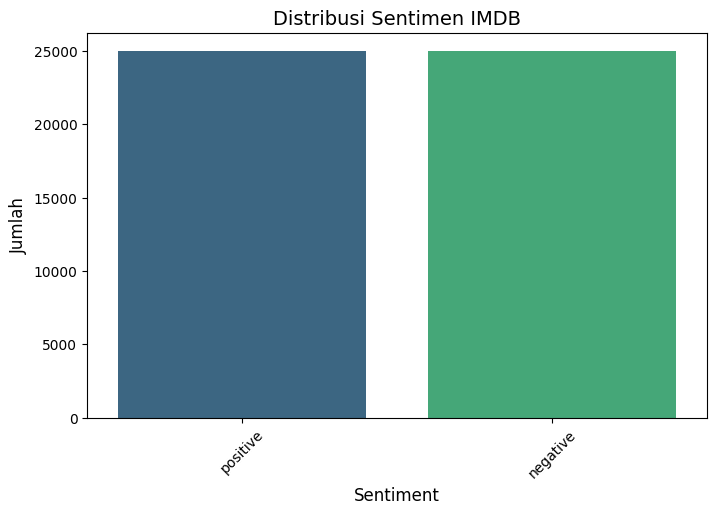

In [4]:
# Distribusi label
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Distribusi Sentimen:")
print("=" * 30)
label_counts = df_raw[LABEL_COL].value_counts()
for label, count in label_counts.items():
    pct = count / len(df_raw) * 100
    print(f"   {label:12s}: {count:5,} ({pct:.1f}%)")
print(f"   {'TOTAL':12s}: {len(df_raw):5,}\n")

# Visualisasi distribusi sentimen menggunakan bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribusi Sentimen IMDB', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=45)
plt.show()

---
## 🧹 Langkah 4: Text Preprocessing (Pembersihan Teks)

Ini adalah langkah **paling penting** dalam NLP! Teks mentah dari review film mengandung banyak noise: tag HTML dari web scraping, kontraksi bahasa Inggris, dan karakter spesial. Kita perlu membersihkannya agar model ML bisa "memahami" teks dengan lebih baik.

### Pipeline Pembersihan Kita:

```text
[ TEKS MENTAH ]
       |
       v
( 1. Lowercase )
       |
       v
( 2. Hapus Tag HTML : <br /> → spasi )
       |
       v
( 3. Hapus URL )
       |
       v
( 4. Ekspansi Kontraksi : can't → cannot )
       |
       v
( 5. Hapus Simbol )
       |
       v
( 6. Hapus Spasi Berlebih )
       |
       v
[ TEKS BERSIH ]
```

> **Perbedaan dengan Module ML1:** Di module sebelumnya kita perlu menangani *leetspeak* dan slang gamer Indonesia. Di sini tantangannya berbeda — review film mengandung **tag HTML** (`<br />`) dan **kontraksi** (`won't`, `can't`) yang harus diekspansi.

In [5]:
# Jalankan pipeline pembersihan teks
df = load_and_clean(csv_path)

📂 Membaca dataset: /home/user/Developer/mct-mlp/module_ML2/data/IMDB Dataset.csv
   Jumlah baris: 50,000
   Kolom: ['review', 'sentiment']
🧹 Membersihkan teks...
✅ Selesai! Jumlah baris bersih: 50,000


In [6]:
# Lihat contoh Before vs After pembersihan
print("🔄 Contoh Hasil Pembersihan (Before → After):")
print("=" * 70)
show_cleaning_examples(df, n=10)

🔄 Contoh Hasil Pembersihan (Before → After):


,original,cleaned,label
33553,"I really liked this Summerslam due to the look of the arena, the curtains an...",i really liked this summerslam due to the look of the arena the curtains and...,positive
9427,Not many television shows appeal to quite as many different kinds of fans li...,not many television shows appeal to quite as many different kinds of fans li...,positive
199,The film quickly gets to a major chase scene with ever increasing destructio...,the film quickly gets to a major chase scene with ever increasing destructio...,negative
12447,Jane Austen would definitely approve of this one!<br /><br />Gwyneth Paltrow...,jane austen would definitely approve of this one gwyneth paltrow does an awe...,positive
39489,"Expectations were somewhat high for me when I went to see this movie, after ...",expectations were somewhat high for me when i went to see this movie after a...,negative
42724,"I've watched this movie on a fairly regular basis for most of my life, and i...",i have watched this movie on a fairly regular basis for most of my life and ...,positive
10822,For once a story of hope highlighted over the tragic reality our youth face....,for once a story of hope highlighted over the tragic reality our youth face ...,positive
49498,"Okay, I didn't get the Purgatory thing the first time I watched this episode...",okay i did not get the purgatory thing the first time i watched this episode...,positive
4144,I was very disappointed with this series. It had lots of cool graphics and t...,i was very disappointed with this series it had lots of cool graphics and th...,negative
36958,"The first 30 minutes of Tinseltown had my finger teetering on the remote, po...",the first minutes of tinseltown had my finger teetering on the remote poised...,negative


In [7]:
# Coba sendiri! Masukkan teks apapun untuk melihat hasilnya
contoh = "This movie can't be WORSE!!! <br /><br />I won't recommend it... https://imdb.com/movie123"
print(f"Input : {contoh}")
print(f"Output: {clean_text(contoh)}")

Input : This movie can't be WORSE!!! <br /><br />I won't recommend it... https://imdb.com/movie123
Output: this movie cannot be worse i will not recommend it


---
## ⚙️ Langkah 5: Setup PyCaret (AutoML)

Sekarang kita masuk ke bagian **Machine Learning**!

### Apa itu PyCaret?
PyCaret adalah framework **AutoML** (Automated Machine Learning) yang memungkinkan kita:
- Membandingkan **beberapa model ML** hanya dengan 1 baris kode
- Melakukan **TF-IDF** secara otomatis (mengubah teks → angka)
- **Tuning hyperparameter** dengan mudah

### Apa itu TF-IDF?
**TF-IDF** (*Term Frequency - Inverse Document Frequency*) adalah cara mengubah teks menjadi vektor angka:
- **TF** = Seberapa sering kata muncul di satu dokumen
- **IDF** = Seberapa "unik" kata tersebut di seluruh dataset  
- Kata yang sering muncul di satu dokumen TAPI jarang di dokumen lain → **nilai TF-IDF tinggi** (kata penting!)

```
Contoh: Kata 'terrible' sering muncul di review negatif, tapi jarang di review positif
        → TF-IDF tinggi untuk label Negative
        → Model belajar: 'terrible' = indikator sentimen negatif!
```

> PyCaret akan otomatis menjalankan TF-IDF karena kita set `text_features=['cleaned_text']`.
> Data akan di-split secara random menjadi 80% train dan 20% test (hold-out).

In [8]:
# Setup PyCaret — ini akan melakukan TF-IDF secara otomatis
setup_pycaret(
    df=df,
    use_gpu=True,
    )

⚙️  Menginisialisasi PyCaret...
   Kolom teks  : cleaned_text
   Kolom label : sentiment
   Train size  : 0.8
   Random seed : 42
   📉 Data di-sample: 50000 → 10000 baris (hemat memori)
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5070, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.0000

,Description,Value
0,Session id,42
1,Target,sentiment
2,Target type,Binary
3,Target mapping,"negative: 0, positive: 1"
4,Original data shape,"(10000, 2)"
5,Transformed data shape,"(10000, 60237)"
6,Transformed train set shape,"(8000, 60237)"
7,Transformed test set shape,"(2000, 60237)"
8,Text features,1
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5070, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

---
## 🏟️ Langkah 6: Model Arena — Membandingkan Model!

Sekarang PyCaret akan **melatih dan mengevaluasi 3 model** pada data test (hold-out set), lalu memberi kita rangking.

### Model yang Akan Dibandingkan:
| Model | Keyword (ID) | Tipe | Keterangan |
|-------|--------------|------|------------|
| Support Vector Machine | `svm` | Kernel (Linear) | Sangat tangguh untuk ruang dimensi tinggi (TF-IDF). |
| Random Forest | `rf` | Ensemble (Bagging) | Stabil, menangani banyak fitur teks tanpa mudah *overfit*. |
| K-Nearest Neighbors | `knn` | Berbasis Jarak | Mengelompokkan teks berdasarkan kemiripan vektor. |

### Metrik Evaluasi:
- **Accuracy** — Persentase prediksi yang benar secara keseluruhan.
- **F1-Score** — *Harmonic mean* antara *Precision* & *Recall* (lebih adil jika jumlah data per kelas tidak seimbang / *imbalanced*).
- **AUC** — *Area Under the ROC Curve* (seberapa baik model memisahkan kelas).

> **Catatan:** Evaluasi dilakukan langsung pada hold-out test set (random split 80/20), tanpa k-fold cross-validation, agar lebih sederhana dan cepat.

In [9]:
# Jalankan Model Arena!
best_models = compare_all_models(
    sort="F1",
    include=['svm', 'rf', 'knn'],
    )

🏟️  Memulai Model Arena (sort by F1)...
   Ini mungkin memakan waktu beberapa menit...



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.8660,0.0000,0.8660,0.8660,0.8660,0.7320,0.7320,22.1300
rf,Random Forest Classifier,0.8105,0.8942,0.8105,0.8107,0.8105,0.6210,0.6212,12.5600
knn,K Neighbors Classifier,0.7115,0.7716,0.7115,0.7159,0.7103,0.4236,0.4276,7.7600



✅ Selesai! Top 5 model telah dipilih.


In [10]:
# Ambil model #1 (terbaik)
if isinstance(best_models, list):
    best = best_models[0]
    print(f"🏆 Model Terbaik: {best}")
else:
    best = best_models
    print(f"🏆 Model Terbaik: {best}")

🏆 Model Terbaik: SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.001, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=42, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)


---
## 🎯 Langkah 7: Tuning Hyperparameter

Model terbaik dari arena sudah bagus, tapi kita bisa **membuatnya lebih bagus** dengan *tuning hyperparameter*.

### Apa itu Hyperparameter?
Hyperparameter adalah "setting" model yang kita atur **sebelum** training:
- Jumlah pohon di Random Forest
- Learning rate di LightGBM
- Regularization strength di SVM

PyCaret akan mencoba berbagai kombinasi hyperparameter dan memilih yang menghasilkan **F1-Score tertinggi**.

In [ ]:
# Tuning model terbaik (opsional — bisa di-skip jika resource terbatas)
# tuned_model = tune_best(best, optimize="F1")

🎯 Tuning hyperparameter (optimize: F1)...


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,11:58:55
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,SVM - Linear Kernel


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


---
## 📊 Langkah 8: Evaluasi Model

Sekarang kita evaluasi model yang sudah di-tune. Kita akan melihat:

### 1. Confusion Matrix
Tabel yang menunjukkan **berapa banyak prediksi yang benar dan salah** untuk setiap label.

```
               Predicted
              Pos    Neg
Actual  Pos [4800]   200    ← 4800 Positive benar, 200 salah
        Neg   300  [4700]   ← 4700 Negative benar, 300 salah
```

### 2. Feature Importance
Kata-kata apa yang paling **berpengaruh** terhadap prediksi model? Ini memberitahu kita: kata apa yang membuat model menganggap sebuah review *positive* atau *negative*?

### 3. Classification Report
Detail **Precision, Recall, dan F1** per label.

In [ ]:
# Confusion Matrix
plot_confusion_matrix(best)

In [ ]:
# Feature Importance — kata apa yang paling mempengaruhi sentimen?
plot_feature_importance(best)

In [ ]:
# Classification Report
plot_class_report(best)

---
## 💾 Langkah 9: Finalize & Export Model

Langkah terakhir! Kita akan:
1. **Finalize** — Melatih ulang model pada **seluruh data** (train + test), bukan hanya data train
2. **Export** — Menyimpan model sebagai file `.pkl` yang bisa dipakai nanti

> **Apa itu file `.pkl`?**  
> `.pkl` (pickle) adalah format serialisasi Python. Model yang disimpan dalam format ini bisa di-*load* kembali di kemudian hari untuk melakukan prediksi — **tanpa perlu training ulang**!

In [ ]:
# Finalize dan simpan model
final_model = finalize_and_save(best)

---
## 🎓 Ringkasan & Poin Penting

### Apa yang Sudah Kita Lakukan:

| Langkah | Apa yang Terjadi | Konsep yang Dipelajari |
|---------|-----------------|----------------------|
| 1. Download | Ambil dataset IMDB dari Kaggle | Data acquisition |
| 2. Eksplorasi | Lihat bentuk & distribusi data (25K pos / 25K neg) | EDA (Exploratory Data Analysis) |
| 3. Preprocessing | Bersihkan teks (HTML tags, kontraksi) | Text normalization |
| 4. Setup PyCaret | Ubah teks → angka (TF-IDF) | Feature extraction |
| 5. Model Arena | Bandingkan banyak model sekaligus | AutoML, model selection |
| 6. Tuning | Optimasi hyperparameter | Hyperparameter tuning |
| 7. Evaluasi | Analisis performa model | Confusion matrix, F1-score |
| 8. Export | Simpan model ke `.pkl` | Model deployment |

### Poin Penting:
- **Preprocessing itu kunci!** Setiap domain memiliki noise yang berbeda — review film punya HTML tags & kontraksi, chat gamer punya leetspeak & slang.
- **TF-IDF** mengubah teks menjadi vektor angka berdasarkan frekuensi dan keunikan kata.
- **AutoML** bukan pengganti pemahaman, tapi alat untuk **eksplorasi cepat** model mana yang paling cocok.
- Dataset IMDB seimbang (50/50), sehingga **Accuracy** dan **F1-Score** memberikan gambaran yang serupa.

### 🔄 Perbandingan dengan Module ML1 (Chat Gamer Indonesia):

| Aspek | Module ML1 (Gamer Chat) | Module ML2 (IMDB Review) |
|-------|------------------------|------------------------|
| Bahasa | Indonesia (slang) | Inggris |
| Panjang Teks | Pendek (chat) | Panjang (review) |
| Noise Utama | Leetspeak, slang gamer | HTML tags, kontraksi |
| Jumlah Kelas | 4 (multiclass) | 2 (binary) |
| Balance | Imbalanced | Balanced (50/50) |
| Jumlah Data | ~10.700 | 50.000 |

---
### 🚀 Langkah Selanjutnya (Sesi 2)
Di sesi berikutnya, kita akan belajar **Deep Learning & Transformer** — pendekatan modern yang jauh lebih canggih untuk NLP!